# 🚀 Advanced RAG Build with Semantic Chunking | 🏗️ XTALLET

### These are the steps I have been following for the Advanced Build

1 . `Baseline LangGraph` RAG Application using `NAIVE RETRIEVAL` <br>
2 . Baseline Evaluation using `RAGAS METRICS`
 - Faithfulness
 - Answer Relevancy
 - Context Precision
 - Context Recall
 - Answer Correctness

3. Implement a `SEMANTIC CHUNKING STRATEGY`. <br>
4. Create an `LangGraph RAG Application` using `SEMANTIC CHUNKING` with `NAIVE RETRIEVAL`. <br>
5. Compare and contrast results.


SEMANTIC CHUNKING REQUIREMENTS:<br>
Chunk semantically similar (based on designed threshold) sentences, and then paragraphs, greedily, up to a maximum chunk size. Minimum chunk size is a single sentence.

## STEP 1: Baseline LangGraph RAG Application using NAIVE RETRIEVAL

<b>Description :</b> This section sets up a basic RAG system using LangGraph, where documents are split into simple chunks and retrieved in a straightforward, traditional way. It’s the starting point to see how everything works by default.

### 🔐 LangChain Setup: Enable Tracing & Set API Key  | 🏗️ XTALLET

> Note : This notebook only requires an OPENAI API Key.

In [1]:
import os
from getpass import getpass
os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

### 📄 Load PDFs from 'data/'  | 🏗️ XTALLET

> NOTE : As the main notebooks I used DirectoryLoader and PyMuPDFLoader to load all PDFs from the 'data' directory.<br>
This is the data our RAG chain will "retrieve" in order to answer queries from the user.

In [2]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader

path = 'data/'
loader = DirectoryLoader(path, glob='*.pdf', loader_cls=PyMuPDFLoader)
docs = loader.load()
print(f'Number of documents loaded: {len(docs)}')

Number of documents loaded: 269


### ✂️ Chunking documents  | 🏗️ XTALLET

> NOTE : As the main notebooks I used RecursiveCharacterTextSplitter to split documents into overlapping chunks.<br>
I included an overlap setting of 200 in order to improve the context of each chunk.

In [3]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
split_documents = text_splitter.split_documents(docs)
print(f'Number of chunks generated: {len(split_documents)}')

Number of chunks generated: 1102


### 🧬 Vectorization and in-memory Qdrant  | 🏗️ XTALLET

> NOTE : As the main notebooks I created embeddings and store the chunks in an in-memory Qdrant vector store.

In [4]:
from langchain_openai import OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
client = QdrantClient(':memory:')
client.create_collection(
    collection_name='loan_data',
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)
vector_store = QdrantVectorStore(
    client=client,
    collection_name='loan_data',
    embedding=embeddings,
)
_ = vector_store.add_documents(documents=split_documents)
print('Vector store created and documents indexed.')

Vector store created and documents indexed.


### 🔎 Define the Retriever  | 🏗️ XTALLET

> NOTE : As the main notebooks I used the Qdrant vector store as a retriever for the RAG pipeline.<br>

It is configured to always return the 5 documents or chunks that are most similar to our question.

In [5]:
retriever = vector_store.as_retriever(search_kwargs={"k": 5})

### 🧩 Retrieval Node Function  | 🏗️ XTALLET

> NOTE : As the main notebooks this function will be used in the LangGraph pipeline to retrieve relevant documents.

In [6]:
def retrieve(state):
    retrieved_docs = retriever.invoke(state["question"])
    return {"context": retrieved_docs}

### 💬 RAG Prompt Template  | 🏗️ XTALLET

> NOTE : As the main notebooks this prompt instructs the LLM to answer only using the provided context.

In [7]:
from langchain.prompts import ChatPromptTemplate

RAG_PROMPT = """\
You are a helpful assistant who answers questions based on the provided context. You must only use the provided context, and cannot use your own knowledge.

### Question
{question}

### Context
{context}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

### 🤖 Generation Node Function  | 🏗️ XTALLET

> NOTE : As the main notebooks this function generates an answer using the retrieved context and the RAG prompt.

In [8]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-nano")

def generate(state):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = rag_prompt.format_messages(question=state["question"], context=docs_content)
    response = llm.invoke(messages)
    return {"response": response.content}

### 🔗 Build LangGraph RAG Pipeline  | 🏗️ XTALLET

> NOTE : As the RAG notebook I used the `add_sequence` since I will always move from retrieval to generation.

In [9]:
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class State(TypedDict):
    question: str
    context: List[Document]
    response: str

graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

### 🗺️ Visualize LangGraph Pipeline Diagram  | 🏗️ XTALLET

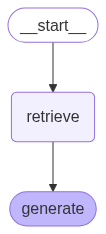

In [10]:
graph

### 🧪 Test Baseline RAG Pipeline  | 🏗️ XTALLET

> NOTE : I am running a test example just to check the pipeline works well.

In [14]:
response = graph.invoke({"question": "What are the different kinds of loans?"})
print(response["response"])

The provided context does not explicitly list different kinds of loans. However, it mentions "Direct Loan" and "Direct Unsubsidized Loan" as types of loans related to student financial assistance.


## STEP 2: Baseline Evaluation using RAGAS METRICS

<b>Description :</b> This section evaluates the basic RAG pipeline using RAGAS metrics, checking things like faithfulness, relevance, and accuracy. It uses generated test questions to get a clear picture of the system’s initial performance.

### 📝 Generate Synthetic Evaluation Dataset  | 🏗️ XTALLET

In [15]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from ragas.testset import TestsetGenerator

generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1"))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)

dataset = generator.generate_with_langchain_docs(split_documents[:20], testset_size=10)

Applying SummaryExtractor:   0%|          | 0/19 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/20 [00:00<?, ?it/s]

Node 764a367f-d89f-4202-a0ca-f5898a572117 does not have a summary. Skipping filtering.


Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/59 [00:00<?, ?it/s]

Applying OverlapScoreBuilder:   0%|          | 0/1 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/2 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/10 [00:00<?, ?it/s]

### 🚀 Run Baseline RAG Pipeline on Evaluation Dataset  | 🏗️ XTALLET

> NOTE : The columns must be explicitly named `response` and `retrieved_contexts` for RAGAS to properly perform the evaluation.<br>
As the main notebooks I am adding both new fields, so RAGAS can later evaluate comparing them with the reference ones.

In [16]:
for test_row in dataset:
    response = graph.invoke({"question": test_row.eval_sample.user_input})
    test_row.eval_sample.response = response["response"]
    test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]

### 🖨️ Display Evaluation Dataset as Pandas DataFrame  | 🏗️ XTALLET

In [17]:
import pandas as pd

df = dataset.to_pandas()
pd.set_option('display.max_colwidth', 200)
display(df)

,user_input,retrieved_contexts,reference_contexts,response,reference,synthesizer_name
0,"Whaat is the main purpsose of the Federal Studnt Aid Handbook as explaind in this volme, and how does it help school finacial aid adminstrators with Title IV aid?","[Volume 3\nAcademic Calendars, Cost of Attendance, and\nPackaging\nIntroduction\nThis volume of the Federal Student Aid (FSA) Handbook discusses the academic calendar, payment period, and\ndisburs...","[Volume 3\nAcademic Calendars, Cost of Attendance, and\nPackaging\nIntroduction\nThis volume of the Federal Student Aid (FSA) Handbook discusses the academic calendar, payment period, and\ndisburs...","The main purpose of the Federal Student Aid Handbook, as explained in this volume, is to provide guidance to school financial aid administrators on the processes related to academic calendars, cos...","This volume of the Federal Student Aid (FSA) Handbook discusses the academic calendar, payment period, and disbursement requirements for awarding aid under the Title IV student financial aid progr...",single_hop_specifc_query_synthesizer
1,Howw do I use the Help Center to give feedbakc on the FSA Handbook?,"[address https://oighotlineportal.ed.gov. The portal provides consistency and improves communication delivery. Because\nthe portal is encrypted, institutions no longer need to encrypt submitted do...","[Education Act of 1965, as amended. Title IV refers to the student financial aid programs authorized under Title IV of the\nHEA.\nWe appreciate any comments that you have on this volume as well as...","To use the Help Center to give feedback on the FSA Handbook, follow these steps:\n\n1. Access the FSA Help Center, which is a collection of additional help and resources, including contact informa...",You can provide feedback on the FSA Handbook by reaching out through the <Contact Customer Support= feature in our Partner Connect9s Help Center and clicking on <FSA Handbook= under the Topic sect...,single_hop_specifc_query_synthesizer
2,wut chnges wer made in 2023-2024 FSA Handbook?,"[Education Act of 1965, as amended. Title IV refers to the student financial aid programs authorized under Title IV of the\nHEA.\nWe appreciate any comments that you have on this volume as well as...","[subscription-based programs.\nChapter 2\nWe have revised the discussion of <Allowable Costs= to clarify that for Pell Grant recipients with an enrollment\nintensity below 50%, the cost of attenda...","The changes made in the 2023-2024 FSA Handbook include:\n\n- In Appendix B of Chapter 1, guidance was added on determining enrollment intensity for Pell Grant recipients enrolled in subscription-b...","The 2023-2024 FSA Handbook incorporated previous changes from the FAFSA Simplification Act, clarified that Pell Grant recipients with enrollment intensity below 50% still have COA based on full-ti...",single_hop_specifc_query_synthesizer
3,"Are bar exam fees considered an allowable cost of attendance (COA) component for students preparing for legal professions, according to the latest federal student aid guidance?","[charged to take a licensing exam, costs associated with applying for and obtaining the license or certification, and bar\nexam fees for law students pursuing a Juris Doctor (JD) degree. Under thi...","[that the guidance in this section pertains to credentials that are required for a student to practice or participate in\nthe occupation the program is preparing the student to enter, and have add...","Yes, bar exam fees are considered an allowable cost of attendance (COA) component for students preparing for legal professions, specifically for law students pursuing a Juris Doctor (JD) degree. T...","Yes, according to the provided guidance, bar exam fees are given as an example of costs that may be included in the cost of attendance (COA) component for credentials required for a student to pra...",single_hop_specifc_query_synthesizer
4,"What Title IV mean for academic year, it gotta be same for all pro

### 📊 Convert to Ragas EvaluationDataset  | 🏗️ XTALLET

In [18]:
from ragas import EvaluationDataset

evaluation_dataset = EvaluationDataset.from_pandas(dataset.to_pandas())

### 🧮 Evaluate with RAGAS Metrics  | 🏗️ XTALLET

Quick notes about each metric :
 - `LLMContextRecall()` : Measures how much of the relevant context was retrieved to answer the question.
 - `Faithfulness()` :  Checks if the answer is strictly supported by the retrieved context.
 - `FactualCorrectness()` : Assesses if the answer is factually correct according to the reference answer.
 - `ResponseRelevancy()` : Evaluates how relevant the answer is to the user's question.
 - `ContextEntityRecall()` : Measures how many key entities from the reference are present in the retrieved context.
 - `NoiseSensitivity()` : Indicates how much irrelevant information (noise) is present in the retrieved context.

In [20]:
from ragas import evaluate
from ragas.llms import LangchainLLMWrapper
from langchain_openai import ChatOpenAI
from ragas.metrics import (
    LLMContextRecall,
    Faithfulness,
    FactualCorrectness,
    ResponseRelevancy,
    ContextEntityRecall,
    NoiseSensitivity
)
from ragas import RunConfig

evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-mini"))
custom_run_config = RunConfig(timeout=360)

result = evaluate(
    dataset=evaluation_dataset,
    metrics=[
        LLMContextRecall(),
        Faithfulness(),
        FactualCorrectness(),
        ResponseRelevancy(),
        ContextEntityRecall(),
        NoiseSensitivity()
    ],
    llm=evaluator_llm,
    run_config=custom_run_config
)
print(result)

Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

{'context_recall': 0.7750, 'faithfulness': 0.8774, 'factual_correctness': 0.5640, 'answer_relevancy': 0.7604, 'context_entity_recall': 0.4178, 'noise_sensitivity_relevant': 0.3244}


## STEP 3: Implement a SEMANTIC CHUNKING STRATEGY

<b>Description :</b> This section introduces a smarter chunking method, grouping together sentences that are semantically similar. The goal is to make each chunk more meaningful and contextually relevant for better retrieval.

### 📦 Install and Download NLTK Data  | 🏗️ XTALLET

I used NLTK to split documents into sentences, enabling fine-grained semantic chunking.
This allows us to group semantically similar sentences together for more meaningful retrieval.

In [21]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /home/xtallet/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/xtallet/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### 🧠 Semantic Chunking Function (Greedy Sentence Grouping)  | 🏗️ XTALLET

This function iterates through each sentence and greedily group it with the current chunk, if it is semantically similar enough; otherwise, start a new chunk.<br>
I used Cosine Similarity to check how each sentence is similar to the others.


In [22]:
import numpy as np
from langchain_openai import OpenAIEmbeddings
from nltk.tokenize import sent_tokenize
from tqdm import tqdm

def semantic_chunk_document(
    text,
    embeddings_model,
    similarity_threshold=0.80,
    max_chunk_size=1000
):
    """
    Greedily group semantically similar sentences into chunks.
    - similarity_threshold: minimum cosine similarity to add a sentence to the current chunk
    - max_chunk_size: maximum number of characters per chunk
    """
    sentences = sent_tokenize(text)
    if not sentences:
        return []
    sentence_embeddings = embeddings_model.embed_documents(sentences)
    chunks = []
    current_chunk = sentences[0]
    current_embedding = sentence_embeddings[0]

    for i in range(1, len(sentences)):
        next_sentence = sentences[i]
        next_embedding = sentence_embeddings[i]
        
        # XTALLET Notes 🏗️ - This is the formula for the cosine similarity
        sim = np.dot(current_embedding, next_embedding) / (
            np.linalg.norm(current_embedding) * np.linalg.norm(next_embedding)
        )
        
        # Check if adding the sentence keeps the chunk semantically coherent and under max size
        if (
            sim >= similarity_threshold
            and len(current_chunk) + len(next_sentence) + 1 <= max_chunk_size
        ):
            current_chunk += " " + next_sentence
            # Update the embedding as the mean of the chunk so far
            current_embedding = (
                np.array(embeddings_model.embed_documents([current_chunk]))[0]
            )
        else:
            chunks.append(current_chunk)
            current_chunk = next_sentence
            current_embedding = next_embedding
    chunks.append(current_chunk)
    return chunks

### 🗂️ Apply Semantic Chunking to All Documents  | 🏗️ XTALLET

> NOTE : The similarity between the current embedding and the next one must be at least 80%<br>

Into the `semantic_chunks` finally I have all the chunks semantically grouped.
Each element is a LangChain Document object, whose page_content is a chunk of text made up of sentences grouped according to their semantic similarity, using the `semantic_chunk_document` function.

In [23]:
semantic_chunks = []
embeddings_model = OpenAIEmbeddings(model='text-embedding-3-small')

for doc in tqdm(docs, desc="Semantic chunking"):
    text = doc.page_content
    doc_chunks = semantic_chunk_document(
        text,
        embeddings_model=embeddings_model,
        similarity_threshold=0.80,
        max_chunk_size=1000
    )
    for chunk in doc_chunks:
        semantic_chunks.append(type(doc)(page_content=chunk, metadata=doc.metadata))

print(f"Number of semantic chunks generated: {len(semantic_chunks)}")

Semantic chunking: 100%|██████████| 269/269 [03:11<00:00,  1.41it/s]

Number of semantic chunks generated: 4533


## STEP 4: LangGraph RAG with SEMANTIC CHUNKING

<b>Description :</b> This section rebuilds the RAG pipeline to use the new semantic chunks, so the system now searches and retrieves from these more coherent blocks. It also includes tests to ensure everything works as expected.

### 🧬 Vectorize Semantic Chunks and Store in Qdrant  | 🏗️ XTALLET

In [24]:
from langchain_openai import OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

semantic_embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
semantic_client = QdrantClient(':memory:')
semantic_client.create_collection(
    collection_name='semantic_chunks',
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)
semantic_vector_store = QdrantVectorStore(
    client=semantic_client,
    collection_name='semantic_chunks',
    embedding=semantic_embeddings,
)
_ = semantic_vector_store.add_documents(documents=semantic_chunks)
print('Semantic vector store created and semantic chunks indexed.')

Semantic vector store created and semantic chunks indexed.


### 🔎 Define the Retriever for Semantic Chunks  | 🏗️ XTALLET

In [25]:
semantic_retriever = semantic_vector_store.as_retriever(search_kwargs={"k": 5})

### 🧩 Retrieval Node Function (Semantic)  | 🏗️ XTALLET

> NOTE : As the main notebooks I used the Qdrant vector store as a retriever for the RAG pipeline, this time using the Semantic.<br>

In [26]:
def semantic_retrieve(state):
    retrieved_docs = semantic_retriever.invoke(state["question"])
    return {"context": retrieved_docs}

### 🔗 Build LangGraph RAG Pipeline (Semantic Chunks)  | 🏗️ XTALLET

> NOTE : I used the `add_sequence` again just to build the same graph but using the semantic chunking in this case.

In [27]:
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class SemanticState(TypedDict):
    question: str
    context: List[Document]
    response: str

semantic_graph_builder = StateGraph(SemanticState).add_sequence([semantic_retrieve, generate])
semantic_graph_builder.add_edge(START, "semantic_retrieve")
semantic_graph = semantic_graph_builder.compile()

### 🗺️ Visualize LangGraph Pipeline Diagram  | 🏗️ XTALLET

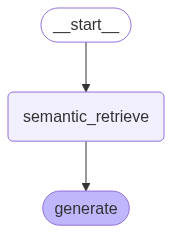

In [28]:
semantic_graph

### 🧪 Test Semantic Chunking RAG Pipeline  | 🏗️ XTALLET

> NOTE : I am running a test example just to check the pipeline works well.

In [29]:
response = semantic_graph.invoke({"question": "What are the different kinds of loans?"})
print(response["response"])

The different kinds of loans mentioned are:

1. Subsidized Federal Stafford Loans
2. Unsubsidized Federal Stafford Loans
3. Federal SLS Loans
4. Federal PLUS Loans
5. Direct Unsubsidized Loans
6. TEACH Grants (note: grants are different from loans but are included in aid options)
7. State loans
8. Private education loans
9. Any other non-need-based loans


## STEP 5: Compare and contrast results

<b>Description :</b> This section compares the results from both the classic and semantic chunking pipelines using the same evaluation metrics. It analyzes and visualizes the outcomes to see if the new approach actually improves performance.

### 🧮 Evaluate Semantic Chunking Pipeline with RAGAS  | 🏗️ XTALLET

As the main notebooks I used `deecopy` to make a copy of the original dataset to avoid overwriting.<br>
The columns must be explicitly named `response` and `retrieved_contexts` for RAGAS to properly perform the evaluation.

In [30]:
from copy import deepcopy

semantic_dataset = deepcopy(dataset)

for test_row in semantic_dataset:
    response = semantic_graph.invoke({"question": test_row.eval_sample.user_input})
    test_row.eval_sample.response = response["response"]
    test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]


### 🖨️ Display Evaluation Semantic Dataset as Pandas DataFrame  | 🏗️ XTALLET

In [35]:
import pandas as pd

df = semantic_dataset.to_pandas()
pd.set_option('display.max_colwidth', 200)
display(df)

,user_input,retrieved_contexts,reference_contexts,response,reference,synthesizer_name
0,"Whaat is the main purpsose of the Federal Studnt Aid Handbook as explaind in this volme, and how does it help school finacial aid adminstrators with Title IV aid?","[This\nvolume of the Federal Student Aid Handbook provides information to assist schools in determining student and parent\neligibility for Direct Loans, counseling student borrowers, and awarding...","[Volume 3\nAcademic Calendars, Cost of Attendance, and\nPackaging\nIntroduction\nThis volume of the Federal Student Aid (FSA) Handbook discusses the academic calendar, payment period, and\ndisburs...","The main purpose of the Federal Student Aid Handbook, as explained in this volume, is to provide information to assist schools in determining student and parent eligibility for Direct Loans, couns...","This volume of the Federal Student Aid (FSA) Handbook discusses the academic calendar, payment period, and disbursement requirements for awarding aid under the Title IV student financial aid progr...",single_hop_specifc_query_synthesizer
1,Howw do I use the Help Center to give feedbakc on the FSA Handbook?,"[We revise the text based on questions and feedback from the financial aid community, so please\nreach out to us about how to improve the FSA Handbook through the <Contact Customer Support= featur...","[Education Act of 1965, as amended. Title IV refers to the student financial aid programs authorized under Title IV of the\nHEA.\nWe appreciate any comments that you have on this volume as well as...","To give feedback on the FSA Handbook using the Help Center, you should use the <Contact Customer Support= feature in the Partner Connect Help Center. Once there, click on <FSA Handbook= under the ...",You can provide feedback on the FSA Handbook by reaching out through the <Contact Customer Support= feature in our Partner Connect9s Help Center and clicking on <FSA Handbook= under the Topic sect...,single_hop_specifc_query_synthesizer
2,wut chnges wer made in 2023-2024 FSA Handbook?,"[These changes are no longer new and were previously incorporated into the 2023-2024 FSA Handbook., We revise the text based on questions and feedback from the financial aid community, so please\n...","[subscription-based programs.\nChapter 2\nWe have revised the discussion of <Allowable Costs= to clarify that for Pell Grant recipients with an enrollment\nintensity below 50%, the cost of attenda...",The changes made in the 2023-2024 FSA Handbook have already been incorporated and are no longer new. The specific details of these changes are not provided in the given context.,"The 2023-2024 FSA Handbook incorporated previous changes from the FAFSA Simplification Act, clarified that Pell Grant recipients with enrollment intensity below 50% still have COA based on full-ti...",single_hop_specifc_query_synthesizer
3,"Are bar exam fees considered an allowable cost of attendance (COA) component for students preparing for legal professions, according to the latest federal student aid guidance?","[We have revised the text under <Costs of Obtaining a License, Certification, or First Professional Credential= to clarify\nthat the guidance in this section pertains to credentials that are requi...","[that the guidance in this section pertains to credentials that are required for a student to practice or participate in\nthe occupation the program is preparing the student to enter, and have add...","Yes, according to the latest federal student aid guidance, bar exam fees are considered an allowable cost of attendance (COA) component for students preparing for legal professions.","Yes, according to the provided guidance, bar exam fees are given as an example of costs that may be included in the cost of attendance (COA) component for credentials required for a student to pra...",single_hop_specifc_query_synthesizer
4,"What Title IV mean for academic year, it gotta be same for all programs or not?","[Although a school may hav

### 📊 Convert to Ragas EvaluationDataset  | 🏗️ XTALLET

In [31]:
from ragas import EvaluationDataset

semantic_evaluation_dataset = EvaluationDataset.from_pandas(semantic_dataset.to_pandas())

### 📊 Evaluate with RAGAS Metrics (Semantic Chunking)  | 🏗️ XTALLET

I am running again the `evaluate` but this time using the semantic dataset.

In [32]:
result_semantic = evaluate(
    dataset=semantic_evaluation_dataset,
    metrics=[
        LLMContextRecall(),
        Faithfulness(),
        FactualCorrectness(),
        ResponseRelevancy(),
        ContextEntityRecall(),
        NoiseSensitivity()
    ],
    llm=evaluator_llm,
    run_config=custom_run_config
)
print("Semantic Chunking RAGAS Results:")
print(result_semantic)

Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

Semantic Chunking RAGAS Results:
{'context_recall': 0.6667, 'faithfulness': 0.7932, 'factual_correctness': 0.6210, 'answer_relevancy': 0.7472, 'context_entity_recall': 0.3254, 'noise_sensitivity_relevant': 0.1594}


### 📈 Compare Baseline vs Semantic Chunking Results  | 🏗️ XTALLET

In [33]:
import pandas as pd

# Try to convert EvaluationResult to dict using .items() or __dict__ fallback
def result_to_dict(res):
    if hasattr(res, "items"):
        return dict(res.items())
    elif hasattr(res, "__dict__"):
        # Sometimes the results are stored in a .results attribute
        if hasattr(res, "results"):
            return res.results
        return res.__dict__
    else:
        raise ValueError("Cannot convert result to dict")

baseline_dict = result_to_dict(result)
semantic_dict = result_to_dict(result_semantic)

df_compare = pd.DataFrame({
    "Baseline": list(baseline_dict.values()),
    "Semantic Chunking": list(semantic_dict.values())
}, index=list(baseline_dict.keys()))

display(df_compare)

,Baseline,Semantic Chunking
scores,"[{'context_recall': 1.0, 'faithfulness': 0.6923076923076923, 'factual_correctness': 0.83, 'answer_relevancy': 0.931957947001883, 'context_entity_recall': 0.4444444439506172, 'noise_sensitivity_rel...","[{'context_recall': 1.0, 'faithfulness': 1.0, 'factual_correctness': 0.59, 'answer_relevancy': 0.9319569509046842, 'context_entity_recall': 0.2222222219753086, 'noise_sensitivity_relevant': 0.3636..."
dataset,"(user_input='Whaat is the main purpsose of the Federal Studnt Aid Handbook as explaind in this volme, and how does it help school finacial aid adminstrators with Title IV aid?' retrieved_contexts=...","(user_input='Whaat is the main purpsose of the Federal Studnt Aid Handbook as explaind in this volme, and how does it help school finacial aid adminstrators with Title IV aid?' retrieved_contexts=..."
binary_columns,[],[]
cost_cb,None,None
traces,"[{'context_recall': {'context_recall_classification_prompt': {'input': QCA(question='Whaat is the main purpsose of the Federal Studnt Aid Handbook as explaind in this volme, and how does it help s...","[{'context_recall': {'context_recall_classification_prompt': {'input': QCA(question='Whaat is the main purpsose of the Federal Studnt Aid Handbook as explaind in this volme, and how does it help s..."
ragas_traces,{'b5677d8f-706b-4ebd-b464-6ef5dc3d0e85': run_id='b5677d8f-706b-4ebd-b464-6ef5dc3d0e85' parent_run_id=None name='ragas evaluation' inputs={} metadata={'type': <ChainType.EVALUATION: 'evaluation'>} ...,{'0fe59ffa-82ea-4d26-aa3f-9e566123916e': run_id='0fe59ffa-82ea-4d26-aa3f-9e566123916e' parent_run_id=None name='ragas evaluation' inputs={} metadata={'type': <ChainType.EVALUATION: 'evaluation'>} ...
run_id,None,None
_scores_dict,"{'context_recall': [1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.5, 0.25, 1.0, 1.0], 'faithfulness': [0.6923076923076923, 1.0, 0.9705882352941176, 1.0, 0.8, 0.8888888888888888, 1.0, 0.75, 0.7222222222222222, 0...","{'context_recall': [1.0, 1.0, 0.0, 1.0, 1.0, 0.6666666666666666, 0.0, 0.5, 0.5, 1.0], 'faithfulness': [1.0, 0.75, 1.0, 1.0, 0.6666666666666666, 0.6153846153846154, 0.8333333333333334, 0.4, 0.75, 0..."
_repr_dict,"{'context_recall': 0.775, 'faithfulness': 0.8774007038712922, 'factual_correctness': 0.564, 'answer_relevancy': 0.760427780467656, 'context_entity_recall': 0.4177777768491526, 'noise_sensitivity_r...","{'context_recall': 0.6666666666666666, 'faithfulness': 0.7932051282051282, 'factual_correctness': 0.6209999999999999, 'answer_relevancy': 0.7472104177278692, 'context_entity_recall': 0.32540403966..."


### 📉 Bar Plot Comparison (Averaged Metrics)  | 🏗️ XTALLET

This code is using `matplotlib` to build the Graph.<br>
It is preparing the `baseline_scores_dict` which contains the first evaluation results and the `semantic_scores_dict` which contains the second evaluation results.<br>
After prepare both, it calculates the average per each metric and finally prepares the `df_plot` dataframe to build the Graph showing both evaluations.

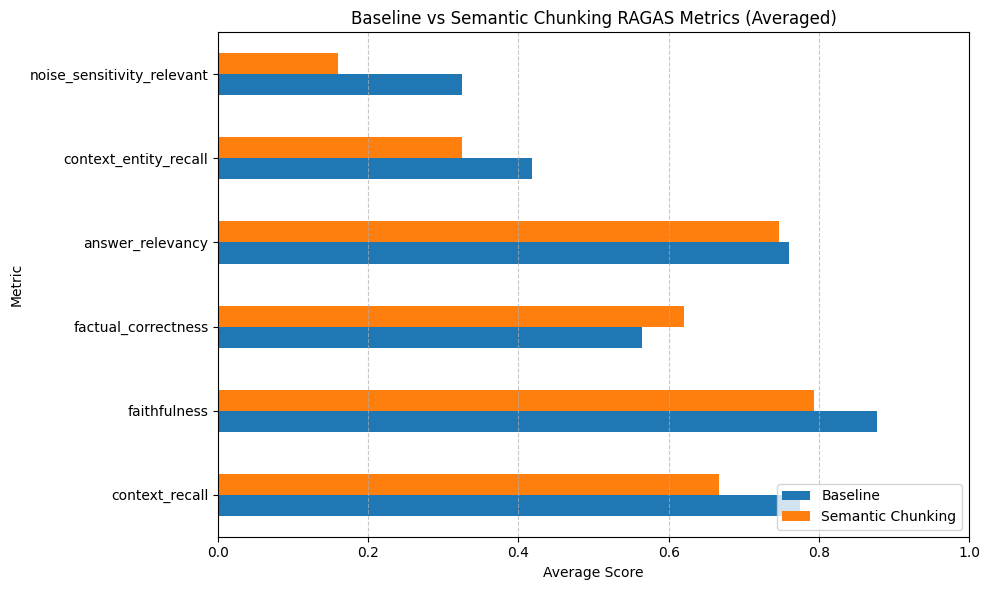

In [34]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 🏗️ XTALLET Notes - Base and Semantic Results
baseline_scores_dict = result._scores_dict
semantic_scores_dict = result_semantic._scores_dict

# 🏗️ XTALLET Notes - Calculate the average of each metric
metric_names = list(baseline_scores_dict.keys())
baseline_means = [float(np.mean(baseline_scores_dict[k])) for k in metric_names]
semantic_means = [float(np.mean(semantic_scores_dict[k])) for k in metric_names]

# 🏗️ XTALLET Notes - Dataframe Creation
df_plot = pd.DataFrame({
    "Baseline": baseline_means,
    "Semantic Chunking": semantic_means
}, index=metric_names)

# 🏗️ XTALLET Notes - Graph
ax = df_plot.round(4).plot(kind='barh', figsize=(10, 6))
plt.title("Baseline vs Semantic Chunking RAGAS Metrics (Averaged)")
plt.xlabel("Average Score")
plt.ylabel("Metric")
plt.xlim(0, 1)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 🏗️ XTALLET - Results

As per the results obtained we can summarize that Semantic Chunking reduces noise and can improve factual correctness, but may lower context recall if chunks are too small or the similarity threshold is too high. Baseline chunking often retrieves more relevant context but includes more irrelevant information.

<b>Baseline Results :</b>
{'context_recall': 0.7750, 'faithfulness': 0.8774, 'factual_correctness': 0.5640, 'answer_relevancy': 0.7604, 'context_entity_recall': 0.4178, 'noise_sensitivity_relevant': 0.3244}

<b>Semantic Chunking Results :</b>
{'context_recall': 0.6667, 'faithfulness': 0.7932, 'factual_correctness': 0.6210, 'answer_relevancy': 0.7472, 'context_entity_recall': 0.3254, 'noise_sensitivity_relevant': 0.1594}

This are my comments comparing both experiments :<br>

 - <b>Context Recall: </b><br><br>
   Baseline (0.7750) is higher than Semantic Chunking (0.6667), meaning the baseline retrieved more relevant context.<br><br>

 - <b>Faithfulness: </b><br><br>
   Baseline (0.8774) is higher than Semantic Chunking (0.7932), indicating the baseline pipeline generates answers that are better supported by the retrieved context.<br><br>

 - <b>Factual Correctness: </b><br><br>
   Semantic Chunking (0.6210) outperforms Baseline (0.5640), suggesting more factually correct answers with semantic chunking.<br><br>

 - <b>Answer Relevancy: </b><br><br>
   Both are similar and relatively high (Baseline: 0.7604, Semantic: 0.7472), showing both approaches generate relevant answers.<br><br>

 - <b>Context Entity Recall: </b><br><br>
   Baseline (0.4178) is higher than Semantic (0.3254), so the baseline retrieved more key entities from the reference..<br><br>

 - <b>Noise Sensitivity: </b><br><br>
   Semantic Chunking (0.1594) is much lower than Baseline (0.3244), meaning semantic chunking includes less irrelevant information (noise) in the retrieved context.<br>

The baseline pipeline retrieves more relevant context and entities, but also more noise.
Semantic chunking reduces noise and improves factual correctness, but at the cost of lower context recall and entity retrieval.